1. Create activity dataset for linear system

In [2]:
%load_ext autoreload
%autoreload 2 --print

In [3]:
import torch as th
import torch.jit as jit
import copy
import numpy as np
import dill
from collections import namedtuple
from torch import optim
from torch import nn
from dynrn.rnntasks import (
    DriscollTasks,
    DriscollPlots,
    period_start_mask,
    periwindows,
    periperiod_sliced,
    split_trials,
    extract_trial_data,
    apply_to_trial_groups,
    nanmean_with_req,
    split_trials_driscoll,
    SimpleTasks,
)
from dynrn.predictors import (
    activity_dataset,
    save_dsn,
    load_dsn,
    discounted_sums,
    MultiBlockActivityDataset,
)
import dynrn.predictors as pred
import dynrn.basic_rnns as rnns
from dynrn.basic_rnns import find_hash
from dynrn.viz import dynamics as vd
import scipy.stats
from cmap import Colormap
from scipy.stats import uniform, norm
from datetime import datetime
from mplutil import util as vu
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.decomposition import PCA
import tqdm
from numpy import linalg as la
import os
import joblib as jl
import time
import seaborn as sns

In [4]:
from dynrn.viz import styles
from dynrn.viz.styles import getc
t20 = lambda x: getc(f"seaborn:tab20{x}")
colors, plotter = styles.init_plt(
    Path('../plots/notebook/vector-td').resolve(),
    fmt = 'pdf', display=False)
plot_root = Path(plotter.plot_dir)

period_colors = {
    "iti": t20("b:5"),
    "context": t20("c:1"),
    "stim": t20("b:2"),
    "memory": t20("b:14"),
    "response": t20("b:10")
}

In [73]:
# cuda setup
device = th.device('cuda' if th.cuda.is_available() else 'cpu')
cpu = th.device('cpu' if th.cuda.is_available() else 'cpu')
print(device.type)

cpu


### Activity dataset for LDS

Create extremely simple test problems for basic models

In [74]:
def linear_dynamics_activity_dataset(matrix, n_sessions, session_length, init_mode = "normal", init_scale = 10.0, seed = 0): 
    """
    Parameters
    ----------
    matrix : np.ndarray, shape (n_dim, n_dim)
        The matrix of linear dynamics.
    n_sessions : int
        Number of sessions.
    session_length : int
        Length of each session.
    init_scale : float
        Scale of the randomly sampled initial conditions
    init_mode : str
        Mode of the initial conditions. Can be 'normal' or 'uniform'.
    seed : int
        Random seed for trajectory initializations

    Returns
    -------
    activity: np.ndarray, shape (n_sessions, session_length, n_dim)
        Generated activity data.
    """
    ndim = matrix.shape[0]
    if init_mode == 'normal':
        init = np.random.randn(n_sessions, ndim) * init_scale
    elif init_mode == 'uniform':
        init = (np.random.rand(n_sessions, ndim) - 0.5) * init_scale
    
    activity = np.zeros((n_sessions, session_length, ndim))
    activity[:, 0, :] = init
    for i in range(1, session_length):
        activity[:, i, :] = np.dot(activity[:, i-1, :], matrix.T)
    
    return activity

    


In [75]:
# ex_matrix = np.array([[0.9, 0.1], [0.1, 0.9]])
# ex_matrix = np.array([[0.9, 0], [0, 0.7]])
ex_matrix = np.array([[0.9, -0.2], [0.1, 0.6]])
# ex_matrix = np.array([[0.8, -0.1], [0.1, 0.8]])
# ex_matrix = np.array([[0.99, -0.3], [0.3, 0.9]])
act_data = linear_dynamics_activity_dataset(
    ex_matrix,
    100,
    100,
    init_mode="normal",
    init_scale=10.0,
    seed=0,
)
x = th.tensor(act_data, device=device, dtype=th.float32)

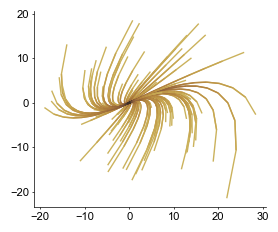

In [76]:
def _():
    fig, ax = plt.subplots(1, 1, figsize=(3, 3))
    timecolors = Colormap('turbid')(np.linspace(0.8, 0.1, 20))
    vd.trajecories(ax, act_data, timecolors)

_()

### First pass model

In [77]:
class NonlinearModelWithSharingAssumptions(nn.Module):
    def __init__(self, ndim, gamma):
        super().__init__()
        self.ndim = ndim
        self.gamma = gamma

        self.str2sn = nn.Linear(ndim, ndim, bias=False)
        self.ctx2str = nn.Linear(ndim, ndim, bias=False)

    @jit.export
    def forward(self, x):
        """
        Parameters
        ----------
        x : torch.Tensor, shape (batch, session_length, ndim)
            Input data to apply the network to

        Returns
        -------
        prediction : torch.Tensor, shape (batch, session_length - 1, ndim)
            Predictions of the network. Note that time t in the output
            uses information from the input at times (t, t+1).
        prediction_error : torch.Tensor, shape (batch, session_length - 1, ndim)
            Prediction errors of the network. Note that time t in the output
            uses information from the input at times (t, t+1).
        """
        # evaluate indirect and direct pathways at all timepoints
        ctxproj = self.ctx2str(x)
        direct = self.str2sn(ctxproj)
        indirect = direct
        # apply delays
        direct = direct[..., 1:, :]  # direct[t] = F(x[t+1])
        indirect = indirect[..., :-1, :]  # indirect[t] = F(x[t])
        ctx2snr = x[..., 1:, :]  # ctx2snr[t] = x[t+1]
        # merge into prediction: p[t] = F(x[t]) - gamma * F(x[t+1])
        # and error: pe[t] = x[t+1] + gamma * F(x[t+1]) - F(x[t])
        p = direct - self.gamma * indirect
        pe = ctx2snr - p
        return p, pe

    @jit.export
    def calculate_update(self, x: th.Tensor, pe: th.Tensor):
        """
        Set parameter gradients to negative desired updates

        Parameters
        ----------
        x : torch.Tensor, shape (batch, session_length, ndim)
            Input data to apply the network to
        pe : torch.Tensor, shape (batch, session_length - 1, ndim)
            Prediction errors to combine with synapse gradients
        """
        with th.no_grad():
            # shape (batch, session_length - 1, ndim, 1)
            # da[t] = pe[t] @ str2sn
            da = (pe @ self.str2sn.weight)[..., None]
            # shape (batch, session_length - 1, ndim, ndim)
            # upd[t] = da[t] @ x[t]
            upd = da * x[..., :-1, None, :]
            self.ctx2str.weight.grad = upd.mean(dim=(0, 1))

    def calculate_loss(self, x: th.Tensor, pe: th.Tensor):
        return (pe ** 2).mean() / 2
    
    def learned_params(self):
        return [self.ctx2str.weight]

In [78]:
def fit_temporal_predictor(model, x, opt, n_steps, loss_every = None, checkpoint_every = None, sgd = False):
    ckpts = {}

    if loss_every is not None:
        losses = np.full([2, n_steps // loss_every + 1], np.nan)
    for step in tqdm.trange(n_steps):
        i = step

        opt.zero_grad()
        _, pe = model.forward(x)
        if sgd:
            loss = model.calculate_loss(x, pe)
            loss.backward()
        else:
            model.calculate_update(x, pe)
        opt.step()
        if loss_every is not None and i % loss_every == 0:
            loss = model.calculate_loss(x, pe)
            losses[0, i // loss_every] = loss.detach().cpu().numpy()
            losses[1, i // loss_every] = step
        
        if checkpoint_every is not None and i % checkpoint_every == 0:
            ckpts[step] = copy.deepcopy(model).cpu()
        
    ret = ()
    if loss_every is not None:
        ret += (losses,)
    if checkpoint_every is not None:
        ret += (ckpts,)
    return ret


def calculate_gradient_alignments(ckpts, x):
    alignments = {}
    for step, model in ckpts.items():
        params = model.learned_params()
        
        # calculate gradients
        for p in params:
            p.grad = None
        _, pe = model.forward(x)
        loss = model.calculate_loss(x, pe)
        with th.no_grad():
            loss.backward()
        g = [p.grad.cpu().numpy() for p in params]
        
        # calculate model prescribed updates
        for p in params:
            p.grad = None
        _, pe = model.forward(x)
        with th.no_grad():
            model.calculate_update(x, pe)
        u = [p.grad.cpu().numpy() for p in params]
        
        # calculate cosine between gradients and updates
        alignments[step] = [
            (g_ * u_).sum() / (la.norm(g_) * la.norm(u_))
            for g_, u_ in zip(g, u)
        ]
    return alignments
            
    

In [79]:
def _():
    
    th.manual_seed(0)
    ganglia = NonlinearModelWithSharingAssumptions(2, 0.9).to(device)
    with th.no_grad():
        ganglia.str2sn.weight.set_(th.eye(2))

    x = th.tensor(act_data, device=device, dtype=th.float32)
    opt = optim.SGD([ganglia.ctx2str.weight], lr=1e-2, momentum=0)

    losses, ckpts = fit_temporal_predictor(
        ganglia, x, opt, n_steps=5000, loss_every=1, checkpoint_every=10
    )

    return dict(ganglia = ganglia, ckpts = ckpts, losses = losses)

sharing_singlepath = _()

 11%|█         | 544/5000 [00:00<00:04, 1089.94it/s]


KeyboardInterrupt: 

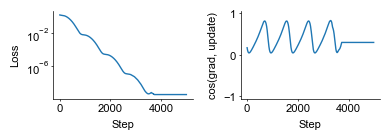

In [ ]:
def _(ckpts, losses):
    alignments = calculate_gradient_alignments(ckpts, x)

    fig, ax = plt.subplots(1, 2, figsize=(4, 1.5))
    ax[0].plot(losses[1], losses[0])
    ax[0].set_xlabel("Step")
    ax[0].set_ylabel("Loss")
    ax[0].set_yscale('log')
    plotter.finalize(fig, None)
    steps = sorted(alignments.keys())
    ax[1].plot(steps, np.stack([alignments[k] for k in steps]))
    ax[1].set_xlabel("Step")
    ax[1].set_ylabel("cos(grad, update)")
    ax[1].set_ylim(-1.05, 1.05)

    return fig

plotter.finalize(_(sharing_singlepath['ckpts'], sharing_singlepath['losses']), None)

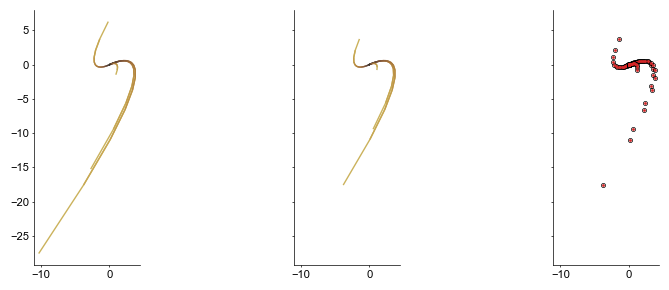

In [ ]:
def _(model):
    
    fig, ax = plt.subplots(1, 3, figsize=(9, 3), sharex=True, sharey=True)
    preds = model(x)[0].detach().cpu().numpy()
    timecolors = Colormap('turbid')(np.linspace(0.8, 0.1, 20))
    for session in [0, 1,2,3]:
        vd.trajecories(ax[0], act_data[[session]], timecolors)
        vd.trajecories(ax[1], preds[[session]], timecolors)
        ax[2].plot(*act_data[session, 1:].T, 'o', ms = 3, mec = 'k', mew=0.5,mfc = (1, 1, 1, 0))
        ax[2].plot(*preds[session].T, 'o', ms = 2, color = 'C3')
        ax[2].set_aspect('equal')
        # stacked = np.stack([act_data[session, 1:], preds[session], preds[session]], axis = -2).reshape(-1, 3, 2)
        # ax[2].plot(stacked[:, 0].T, stacked[:, 1].T, 'ko-', ms = 1, lw = 0.5)
    return fig

plotter.finalize(_(sharing_singlepath['ganglia']), None)

#### SGD

100%|██████████| 500/500 [00:00<00:00, 2189.06it/s]


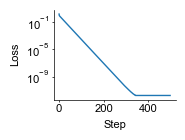

In [ ]:
def _():
    ganglia = NonlinearModelWithSharingAssumptions(2, 0.9).to(device)
    with th.no_grad():
        ganglia.str2sn.weight.set_(th.eye(2))

    x = th.tensor(act_data, device=device, dtype=th.float32)
    opt = optim.SGD([ganglia.ctx2str.weight], lr=5e0, momentum=0)

    losses, ckpts = fit_temporal_predictor(
        ganglia, x, opt, n_steps=500, loss_every=1, checkpoint_every=10, sgd=True
    )

    fig, ax = plt.subplots(1, 1, figsize=(2, 1.5))
    ax.plot(losses[1], losses[0])
    ax.set_xlabel("Step")
    ax.set_ylabel("Loss")
    ax.set_yscale('log')
    plotter.finalize(fig, None)

_()

### Dual path gradient model

The previous model doesn't work, but this might not be particularly surprising.
In particular the parameter update didn't match the gradient of the TD loss,
since the update was applied to both the indirect and direct pathway weights
despite being calculated only w.r.t the direct pathway weights.

In [ ]:
class NonlinearModelWithSharingAssumptions_DualPath(NonlinearModelWithSharingAssumptions):

    @jit.export
    def calculate_update(self, x: th.Tensor, pe: th.Tensor):
        """
        Set parameter gradients to negative desired updates

        Parameters
        ----------
        x : torch.Tensor, shape (batch, session_length, ndim)
            Input data to apply the network to
        pe : torch.Tensor, shape (batch, session_length - 1, ndim)
            Prediction errors to combine with synapse gradients
        """
        with th.no_grad():
            # shape (batch, session_length - 1, ndim, 1)
            # da[t] = str2sn.T @ pe[t]
            # - function of x[t], x[t+1]
            da = (pe @ self.str2sn.weight)[..., None]
            # shape (batch, session_length - 1, 1, ndim)
            # inp_trace[t] = x[t] - gamma * x[t+1]
            inp_trace = x[..., :-1, None, :] - self.gamma * x[..., 1:, None, :]
            # shape (batch, session_length - 1, ndim, ndim)
            # upd_trace[ij] = da[i] * inp_trace[j]
            upd = da * inp_trace
            # opt applies negative of grad
            self.ctx2str.weight.grad = upd.mean(dim=(0, 1)) 

    def calculate_loss(self, x: th.Tensor, pe: th.Tensor):
        return (pe ** 2).mean() / 2
    
    def learned_params(self):
        return (self.ctx2str.weight,)

In [ ]:
def _():
    
    th.manual_seed(0)
    ganglia = NonlinearModelWithSharingAssumptions_DualPath(2, 0.9).to(device)
    with th.no_grad():
        ganglia.str2sn.weight.set_(th.eye(2))

    x = th.tensor(act_data, device=device, dtype=th.float32)
    opt = optim.SGD([ganglia.ctx2str.weight], lr=5e-2, momentum=0)

    losses, ckpts = fit_temporal_predictor(
        ganglia, x, opt, n_steps=5000, loss_every=1, checkpoint_every=10
    )

    return dict(ckpts = ckpts, losses = losses)

sharing_dualpath = _()

100%|██████████| 5000/5000 [00:02<00:00, 1800.38it/s]


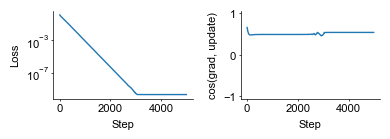

In [ ]:
def _(ckpts, losses):
    alignments = calculate_gradient_alignments(ckpts, x)

    fig, ax = plt.subplots(1, 2, figsize=(4, 1.5))
    ax[0].plot(losses[1], losses[0])
    ax[0].set_xlabel("Step")
    ax[0].set_ylabel("Loss")
    ax[0].set_yscale('log')
    plotter.finalize(fig, None)
    steps = sorted(alignments.keys())
    ax[1].plot(steps, [alignments[k] for k in steps])
    ax[1].set_xlabel("Step")
    ax[1].set_ylabel("cos(grad, update)")
    ax[1].set_ylim(-1.05, 1.05)

    return fig

plotter.finalize(_(sharing_dualpath['ckpts'], sharing_dualpath['losses']), None)

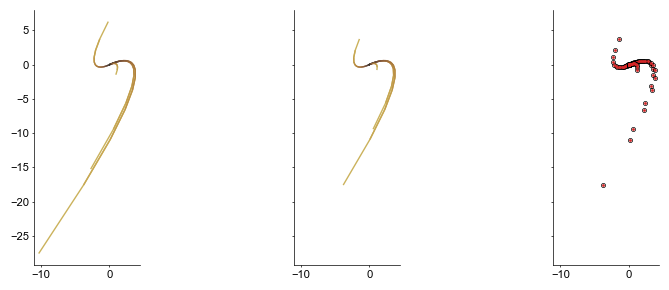

In [ ]:
def _(model):
    
    fig, ax = plt.subplots(1, 3, figsize=(9, 3), sharex=True, sharey=True)
    preds = model(x)[0].detach().cpu().numpy()
    timecolors = Colormap('turbid')(np.linspace(0.8, 0.1, 20))
    for session in [0, 1,2,3]:
        vd.trajecories(ax[0], act_data[[session]], timecolors)
        vd.trajecories(ax[1], preds[[session]], timecolors)
        ax[2].plot(*act_data[session, 1:].T, 'o', ms = 3, mec = 'k', mew=0.5,mfc = (1, 1, 1, 0))
        ax[2].plot(*preds[session].T, 'o', ms = 2, color = 'C3')
        ax[2].set_aspect('equal')
        # stacked = np.stack([act_data[session, 1:], preds[session], preds[session]], axis = -2).reshape(-1, 3, 2)
        # ax[2].plot(stacked[:, 0].T, stacked[:, 1].T, 'ko-', ms = 1, lw = 0.5)
    return fig

plotter.finalize(_(sharing_singlepath['ganglia']), None)

### Separated pathways

Also removed: identity-matrix in striatonigral pathway

In [ ]:
class LinearRecurrentShare_IndPath(nn.Module):
    def __init__(self, ndim, gamma):
        super().__init__()
        self.ndim = ndim
        self.gamma = gamma

        self.d2sn = nn.Linear(ndim, ndim, bias=False)
        self.i2sn = nn.Linear(ndim, ndim, bias=False)
        self.ctx2i = nn.Linear(ndim, ndim, bias=False)
        self.ctx2d = nn.Linear(ndim, ndim, bias=False)

    @jit.export
    def forward(self, x):
        """
        Parameters
        ----------
        x : torch.Tensor, shape (batch, session_length, ndim)
            Input data to apply the network to

        Returns
        -------
        prediction : torch.Tensor, shape (batch, session_length - 1, ndim)
            Predictions of the network. Note that time t in the output
            uses information from the input at times (t, t+1).
        prediction_error : torch.Tensor, shape (batch, session_length - 1, ndim)
            Prediction errors of the network. Note that time t in the output
            uses information from the input at times (t, t+1).
        """
        # evaluate indirect and direct pathways at all timepoints
        str_d = self.ctx2d(x)
        str_i = self.ctx2i(x)
        direct = self.d2sn(str_d)
        indirect = self.i2sn(str_i)
        # apply delays
        direct = direct[..., 1:, :]  # direct[t] = F_d(x[t+1])
        indirect = indirect[..., :-1, :]  # indirect[t] = F_i(x[t])
        ctx2snr = x[..., 1:, :]  # ctx2snr[t] = x[t+1]
        # merge into prediction: p[t] = F_i(x[t]) - gamma * F_d(x[t+1])
        # and error: pe[t] = x[t+1] + gamma * F_d(x[t+1]) - F_i(x[t])
        p = direct - self.gamma * indirect
        pe = ctx2snr - p
        return p, pe

    @jit.export
    def calculate_update(self, x: th.Tensor, pe: th.Tensor):
        """
        Set parameter gradients to negative desired updates

        Parameters
        ----------
        x : torch.Tensor, shape (batch, session_length, ndim)
            Input data to apply the network to
        pe : torch.Tensor, shape (batch, session_length - 1, ndim)
            Prediction errors to combine with synapse gradients
        """
        with th.no_grad():
            # shape (batch, session_length - 1, ndim, 1)
            # da_(d/i)[t] = (d/i)2sn.T @ pe[t]
            # - function of x[t], x[t+1]
            da_d = (pe @ self.d2sn.weight)[..., None]
            da_i = (pe @ self.i2sn.weight)[..., None]
            # shape (batch, session_length - 1, ndim, ndim)
            # upd_d[t] = da_d[t] @ x[t+1]
            # upd_i[t] = da_i[t] @ x[t]
            upd_d = -self.gamma * da_d * x[..., 1:, None, :]
            upd_i = da_i * x[..., :-1, None, :]
            # optimizer applies negative of grad
            self.ctx2d.weight.grad = upd_d.mean(dim=(0, 1))
            self.ctx2i.weight.grad = upd_i.mean(dim=(0, 1))

    def calculate_loss(self, x: th.Tensor, pe: th.Tensor):
        return (pe ** 2).mean() / 2
    
    def learned_params(self):
        return (self.ctx2d.weight, self.ctx2i.weight)

In [ ]:
def _():
    
    th.manual_seed(0)
    ganglia = LinearRecurrentShare_IndPath(2, 0.9).to(device)
    # with th.no_grad():
        # ganglia.i2sn.weight.set_(th.eye(2))
        # ganglia.d2sn.weight.set_(th.eye(2))
    
    x = th.tensor(act_data, device=device, dtype=th.float32)
    opt = optim.SGD(ganglia.learned_params(), lr=5e-2, momentum=0)

    losses, ckpts = fit_temporal_predictor(
        ganglia, x, opt, n_steps=5000, loss_every=1, checkpoint_every=10
    )

    return dict(ckpts = ckpts, losses = losses)

sharing_dualpath = _()

100%|██████████| 5000/5000 [00:05<00:00, 985.06it/s] 


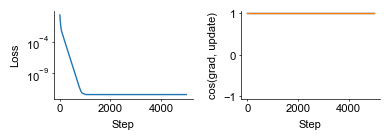

In [ ]:
def _(ckpts, losses):
    alignments = calculate_gradient_alignments(ckpts, x)

    fig, ax = plt.subplots(1, 2, figsize=(4, 1.5))
    ax[0].plot(losses[1], losses[0])
    ax[0].set_xlabel("Step")
    ax[0].set_ylabel("Loss")
    ax[0].set_yscale('log')
    plotter.finalize(fig, None)
    steps = sorted(alignments.keys())
    ax[1].plot(steps, [alignments[k] for k in steps])
    ax[1].set_xlabel("Step")
    ax[1].set_ylabel("cos(grad, update)")
    ax[1].set_ylim(-1.05, 1.05)

    return fig

plotter.finalize(_(sharing_dualpath['ckpts'], sharing_dualpath['losses']), None)

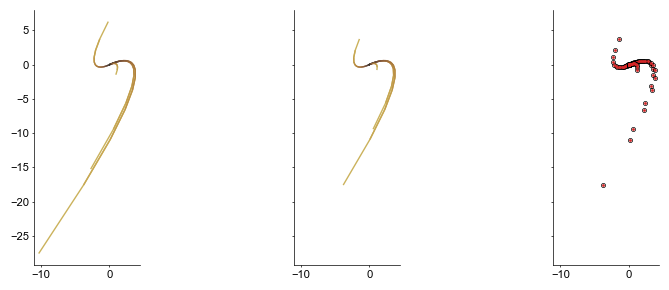

In [ ]:
def _(model):
    
    fig, ax = plt.subplots(1, 3, figsize=(9, 3), sharex=True, sharey=True)
    preds = model(x)[0].detach().cpu().numpy()
    timecolors = Colormap('turbid')(np.linspace(0.8, 0.1, 20))
    for session in [0, 1,2,3]:
        vd.trajecories(ax[0], act_data[[session]], timecolors)
        vd.trajecories(ax[1], preds[[session]], timecolors)
        ax[2].plot(*act_data[session, 1:].T, 'o', ms = 3, mec = 'k', mew=0.5,mfc = (1, 1, 1, 0))
        ax[2].plot(*preds[session].T, 'o', ms = 2, color = 'C3')
        ax[2].set_aspect('equal')
        # stacked = np.stack([act_data[session, 1:], preds[session], preds[session]], axis = -2).reshape(-1, 3, 2)
        # ax[2].plot(stacked[:, 0].T, stacked[:, 1].T, 'ko-', ms = 1, lw = 0.5)
    return fig

plotter.finalize(_(sharing_singlepath['ganglia']), None)

### Laplace solution

Can a variety of discount rates be used to construct the forward transform?

In [5]:
import scipy.ndimage


ns = 900
filter_length = 200
rng = np.random.default_rng(0)
theta = rng.uniform(-np.pi / 4, np.pi / 4, ns) * 0
r = np.sqrt(rng.uniform(0, 1, ns))
s = np.cos(theta) * r + np.sin(theta) * r * 1j
laplace_filters = s[:, None] ** np.arange(filter_length)[None, :]

nt = 1000
nex = 100
smoothing = 2
signals = np.cumsum((4 * rng.normal(size=(nex, nt + smoothing * 2))) ** 3 / nt * 10, axis = -1)
signals = np.lib.stride_tricks.sliding_window_view(signals, smoothing * 2 + 1, axis = -1).sum(axis = -1)

bwd_conv = np.array([[
    np.convolve(signals[iex], laplace_filters[ifilt], mode='valid')
    for ifilt in range(ns)] for iex in tqdm.trange(nex)])

100%|██████████| 100/100 [00:07<00:00, 12.86it/s]


In [329]:
dill.dump(bwd_conv, open('/tmp/bwd_conv.dill', 'wb'))

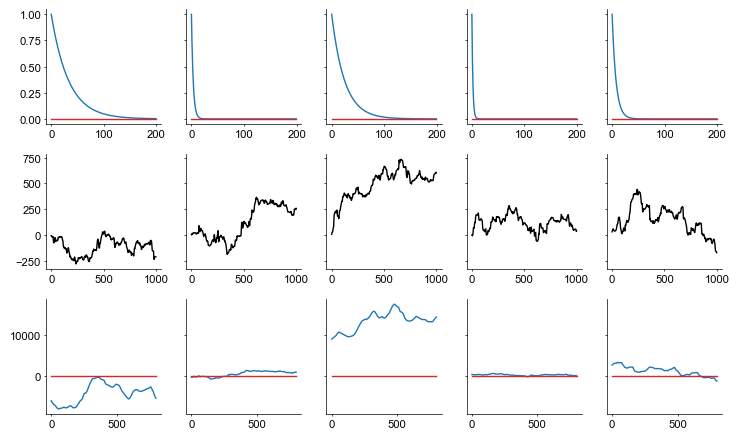

In [6]:
fig, ax = plt.subplots(3, 5, figsize = (7.5, 4.5), sharex='row', sharey='row')
for i in range(5):
    ax[0, i].plot(laplace_filters[i].real, 'C0-', lw = 1)
    ax[0, i].plot(laplace_filters[i].imag, 'C3-', lw = 1)
    ax[1, i].plot(signals[i], 'k-', lw = 1)
    ax[2, i].plot(bwd_conv[i, i].real, 'C0-', lw = 1)
    ax[2, i].plot(bwd_conv[i, i].imag, 'C3-', lw = 1)
plotter.finalize(fig, None)

In [9]:
# Sanity check on understanding laplace transform:
# Can you reconstruct the input signal from the convolved data?
# Answer: yes!

# For filter length L: construct X[ex, t=T:T+L] from U[ex, :, t=T+L (index T)]
# Y[ex, T, t'] = sum_j A_t'j U[ex, j, t=T+L (index T)]
# With reindexed U'[s, ex, T] and A[t', s], want X[t'=T:T+L ex, T] = (A @ U')
X = np.lib.stride_tricks.sliding_window_view(signals, filter_length, axis = -1).transpose(2, 0, 1)
U = np.concatenate([bwd_conv.real, bwd_conv.imag], axis = 1).transpose(1, 0, 2)

In [10]:
X.shape, U.shape

((200, 100, 801), (1800, 100, 801))

In [11]:
from sklearn.linear_model import LinearRegression
n_train = 10
n_test = 10
X_train, U_train = X[:, :n_train], U[:, :n_train]
X_test,  U_test  = X[:, -n_test:], U[:, -n_test:]

Xtr, Utr = X_train.reshape(filter_length, -1), U_train.reshape(2 * ns, -1)
Xte, Ute = X_test.reshape(filter_length, -1), U_test.reshape(2 * ns, -1)
print(Xtr.shape, Utr.shape)

(200, 8010) (1800, 8010)


In [12]:
F = LinearRegression().fit(Utr.T, Xtr.T)
Xhat_test = F.predict(Ute.T).T.reshape(filter_length, n_test, -1)

In [13]:
np.mean((Xhat_test - X_test) ** 2)

np.float64(107.24641412619356)

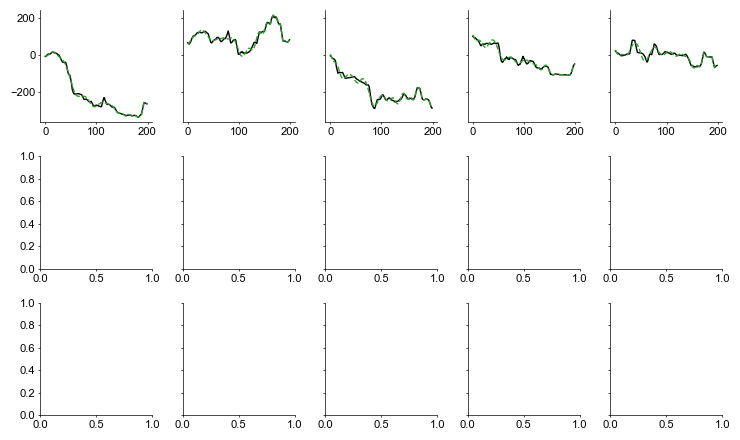

In [14]:
fig, ax = plt.subplots(3, 5, figsize = (7.5, 4.5), sharex='row', sharey='row')
for i in range(5):
    ax[0, i].plot(X_test[:, i, i * 10], 'k-', lw = 1)
    ax[0, i].plot(Xhat_test[:, i, i * 10], 'C2--', lw = 1)
plotter.finalize(fig, None)

In [15]:
# Ultimate question for forward-facing: can you construct it from sum of
# backward facing?
# Seek M such that X[ex, T, t=T+t'] = sum_s M[t', s] sum_k U[s, ex, T, t''=T+k] g^k

In [16]:
gwindow = 100
g = 0.99
n_train, n_test = 50, 50

gk = g ** np.arange(gwindow)
U_window = np.lib.stride_tricks.sliding_window_view(U[:, :n_train + n_test], gwindow, axis = -1)
U_sum = U_window @ gk
X = np.lib.stride_tricks.sliding_window_view(signals[:n_train + n_test], filter_length, axis = -1).transpose(2, 0, 1)

# U_sum[s, ex, k] function of signals[ex, k : (k + filter_length + gwindow)]
# X[t'=0:filter_length, ex, k] function of signals[ex, k : (k + filter_length)]
# To predict the last `filter_length` chunk of `signal`, use the last element of `U_sum`
X = X[:, :, -U_sum.shape[-1]:]

In [17]:
X_train, U_train = X[:, :n_train], U_sum[:, :n_train]
X_test,  U_test  = X[:, -n_test:], U_sum[:, -n_test:]
Xtr, Utr = X_train.reshape(filter_length, -1).T, U_train.reshape(2 * ns, -1).T
Xte, Ute = X_test.reshape(filter_length, -1).T, U_test.reshape(2 * ns, -1).T

In [18]:
X_train.shape, U_train.shape, Xtr.shape, Utr.shape

((200, 50, 702), (1800, 50, 702), (35100, 200), (35100, 1800))

In [19]:
from sklearn.linear_model import Lasso
# U_scales = Utr.std(axis = 1, keepdims=True)
# Utr_scaled = Utr / U_scales
# Ute_scaled = Ute / U_scales
# X_scales = Xtr.std(axis = 1, keepdims=True)
# Xtr_scaled = Xtr / X_scales
# Xte_scaled = Xte / X_scales

F = LinearRegression().fit(Utr, Xtr)
Xhat_train = F.predict(Utr).T.reshape(filter_length, n_train, -1)
Xhat_test = F.predict(Ute).T.reshape(filter_length, n_test, -1)

In [20]:
np.mean((Xhat_train - X_train) ** 2), np.mean((Xhat_test - X_test) ** 2)

(np.float64(696.3860601999745), np.float64(652.2938031284168))

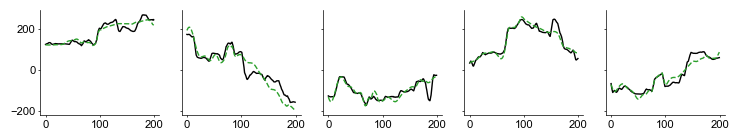

In [21]:
fig, ax = plt.subplots(1, 5, figsize = (7.5, 1.5), sharex='row', sharey='row')
for i in range(5):
    ax[i].plot(X_test[:, i, i * 10], 'k-', lw = 1)
    ax[i].plot(Xhat_test[:, i, i * 10], 'C2--', lw = 1)
plotter.finalize(fig, None)

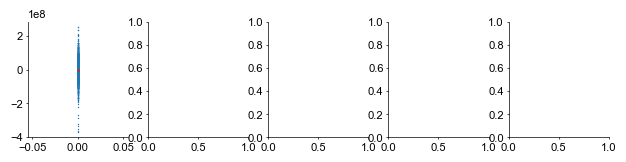

In [22]:
fig, ax = plt.subplots(1, 5, figsize = (7.5, 1.5))
for t in range(filter_length):
    ax[0].plot(theta, F.coef_[t, :ns], 'C0o', mew = 0, ms = 1)
    ax[0].plot(theta, F.coef_[t, ns:], 'C3o', mew = 0, ms = 1)

In [26]:
nkeep = 5
best_s = np.union1d(
    np.argsort(np.abs(F.coef_[:, :ns]).sum(axis = 0))[:nkeep],
    np.argsort(np.abs(F.coef_[:, ns:]).sum(axis = 0))[:nkeep],
)
keep_s = np.concatenate([best_s, best_s + ns])
nkept = len(keep_s)
Ub_train = U_sum[keep_s, :n_train]
Ub_test  = U_sum[keep_s, -n_test:]
Ubtr = Ub_train.reshape(nkept, -1).T
Ubte = Ub_test.reshape(nkept, -1).T

In [27]:
Ub_train.shape, X_train.shape

((20, 50, 702), (200, 50, 702))

In [28]:
Ubtr = Ub_train.reshape(nkept, -1).T
Ubtr = Ubtr + rng.normal(scale = 1, size = Ubtr.shape)
Fb = LinearRegression().fit(Ubtr, Xtr)
Xbhat_train = Fb.predict(Ubtr).T.reshape(filter_length, n_train, -1)
Xbhat_test = Fb.predict(Ubte).T.reshape(filter_length, n_test, -1)
noi_btrn = rng.normal(scale = 1, size = Ubtr.shape)
noi_btes = rng.normal(scale = 1, size = Ubte.shape)
Ubtr_clean = Ub_train.reshape(nkept, -1).T
noi_Xbhat_train = Fb.predict(Ubtr_clean + noi_btrn).T.reshape(filter_length, n_train, -1)
noi_Xbhat_test = Fb.predict(Ubte + noi_btes).T.reshape(filter_length, n_test, -1)

In [29]:
print("Train error", np.mean((Xbhat_train - X_train) ** 2))
print("Test error", np.mean((Xbhat_test - X_test) ** 2))
print("Train error (with different noise)", np.mean((noi_Xbhat_train - X_train) ** 2))
print("Test error (with noise)", np.mean((noi_Xbhat_test - X_test) ** 2))

Train error 876.9316944366865
Test error 819.6717266612277
Train error (with different noise) 877.2666702057837
Test error (with noise) 828.6086585154411


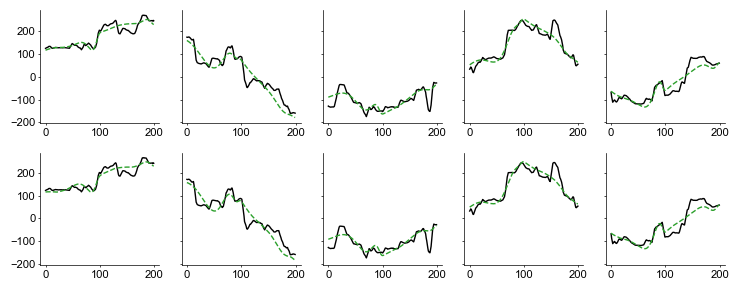

In [30]:
fig, ax = plt.subplots(2, 5, figsize = (7.5, 3), sharex='row', sharey='row')
for i in range(5):
    ax[0, i].plot(X_test[:, i, i * 10], 'k-', lw = 1)
    ax[0, i].plot(Xbhat_test[:, i, i * 10], 'C2--', lw = 1)
    ax[1, i].plot(X_test[:, i, i * 10], 'k-', lw = 1)
    ax[1, i].plot(noi_Xbhat_test[:, i, i * 10], 'C2--', lw = 1)
plotter.finalize(fig, None)

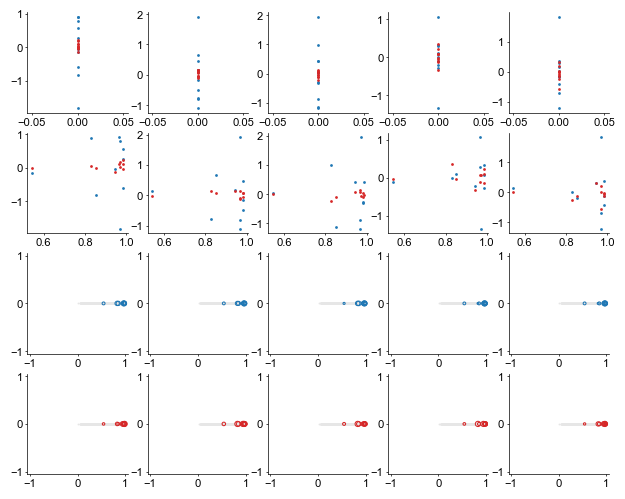

In [31]:
fig, ax = plt.subplots(4, 5, figsize = (7.5, 6))
for i in range(5):
    T = int(i * filter_length / 5)
    ax[0, i].plot(theta[keep_s[:nkept // 2]], Fb.coef_[T, :nkept // 2], 'C0o', mew = 0, ms = 2)
    ax[0, i].plot(theta[keep_s[:nkept // 2]], Fb.coef_[T, nkept // 2:], 'C3o', mew = 0, ms = 2)
    ax[1, i].plot(r[keep_s[:nkept // 2]], Fb.coef_[T, :nkept // 2], 'C0o', mew = 0, ms = 2)
    ax[1, i].plot(r[keep_s[:nkept // 2]], Fb.coef_[T, nkept // 2:], 'C3o', mew = 0, ms = 2)
    normed_size = abs(Fb.coef_[T, :nkept // 2])
    normed_size = np.sqrt(200 * normed_size / normed_size.max() + 2)
    r_ = r[keep_s[:nkept // 2]]
    thet_ = theta[keep_s[:nkept // 2]]
    ax[2, i].scatter(r_ * np.cos(thet_), r_ * np.sin(thet_), s = normed_size, color = (1, 1, 1, 0), edgecolors = 'C0', linewidths = 0.75)
    ax[2, i].set_xlim(-1.05, 1.05 )
    ax[2, i].set_ylim(-1.05, 1.05)
    ax[2, i].scatter(r * np.cos(theta), r * np.sin(theta), color = '.9', s = 0.3, zorder = -2)
    normed_size = abs(Fb.coef_[T, nkept // 2:])
    normed_size = np.sqrt(200 * normed_size / normed_size.max() + 2)
    r_ = r[keep_s[:nkept // 2]]
    thet_ = theta[keep_s[:nkept // 2]]
    ax[3, i].scatter(r_ * np.cos(thet_), r_ * np.sin(thet_), s = normed_size, color = (1, 1, 1, 0), edgecolors = 'C3', linewidths = 0.75)
    ax[3, i].scatter(r * np.cos(theta), r * np.sin(theta), color = '.9', s = 0.3, zorder = -2)
    ax[3, i].set_xlim(-1.05, 1.05 )
    ax[3, i].set_ylim(-1.05, 1.05)

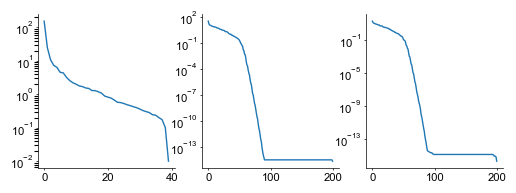

In [402]:
fig, ax = plt.subplots(1, 3, figsize = (6, 2))
ax[0].plot(np.linalg.svd(Fb.coef_)[1])
ax[0].set_yscale('log')
ax[1].plot(np.linalg.svd(laplace_filters.real)[1])
ax[1].set_yscale('log')
ax[2].plot(np.linalg.svd(laplace_filters.imag)[1])
ax[2].set_yscale('log')


In [398]:
laplace_filters.shape

(900, 200)